In [1]:
from langchain.chat_models import init_chat_model 
from typing_extensions import TypedDict 
from langgraph.graph import StateGraph , START , END
from IPython.display import Image, display
from dotenv import load_dotenv

load_dotenv()  # Load environment variables from .env file

True

In [ ]:
model = init_chat_model(
    model_provider="google_genai", 
                        model ="gemini-2.5-flash",
                        temperature=0.7,
                        max_output_tokens=1024,
                        top_p=0.95,
                        top_k=40,
                        timeout = 30,
                        max_retries = 3,
                        load_env=True
)

In [3]:
class State(TypedDict):
    topic : str
    joke : str
    story : str
    poem : str 
    combined_output: str

In [4]:
def llm_call1(state : State):
    """First LLM call to generate initial joke"""

    msg = model.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}

In [5]:
def llm_call2(state : State):
    """Second LLM call to generate a story"""

    msg = model.invoke(f"Write a Story about {state['topic']}")
    return {"story": msg.content}

In [6]:
def llm_call3(state : State):
    """Third LLM call to generate a poem"""

    msg = model.invoke(f"Write a Poem about {state['topic']}")
    return {"poem": msg.content}

In [7]:
def aggregator(state : State):
    """Combine the joke, story and poem into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}

In [17]:
parallel_builder = StateGraph(State)

In [18]:
parallel_builder.add_node("call_llm1", llm_call1)
parallel_builder.add_node("call_llm2", llm_call2)
parallel_builder.add_node("call_llm3", llm_call3)
parallel_builder.add_node("aggregate", aggregator)

In [19]:
parallel_builder.add_edge(START, "call_llm1")
parallel_builder.add_edge(START, "call_llm2")
parallel_builder.add_edge(START, "call_llm3")

In [20]:
parallel_builder.add_edge("call_llm1", "aggregate")
parallel_builder.add_edge("call_llm2", "aggregate")
parallel_builder.add_edge("call_llm3", "aggregate")
parallel_builder.add_edge("aggregate", END)

In [22]:
parallel_workflow = parallel_builder.compile()

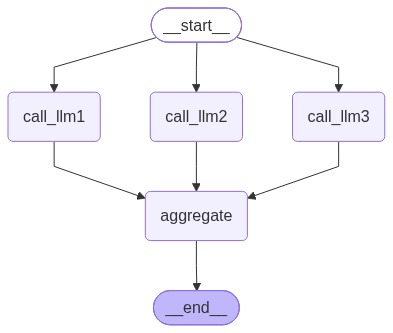

In [23]:
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

In [24]:
state = parallel_workflow.invoke({"topic": "cats"})
print(state["combined_output"])

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Here's a story, joke, and poem about cats!

STORY:
Luna was a creature of comfort, a sleek, midnight-black cat with eyes like polished emeralds. Her days were a languid ballet of sunbeams, soft cushions, and the rhythmic purr

JOKE:
Why did the cat sit on the computer keyboard?

Because it wanted to keep an eye on its human's important work... and maybe send a few "meow" emails.

POEM:
A sleek shadow, a velvet paw,
A creature guided by ancient law.
With eyes of emerald, gold, or blue,
They gaze right through, and through, and through.

A silent hunter, lithe and lean,
A graceful, captivating scene.
From sunlit nap to sudden sprint,
Each motion holds a subtle hint
Of wildness tamed, but never lost,
A spirit free, at any cost.

They stretch and yawn, a dainty maw,
Then knead the air with velvet paw.
A purring engine, soft and deep,
While curled in slumber, fast asleep.
Upon a lap, a gentle weight,
They choose their love, they seal their fate.

A twitching whisker, keen and bright,
Explor